<a href="https://colab.research.google.com/github/Dijah-Tunrayo/Lab_3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cuda


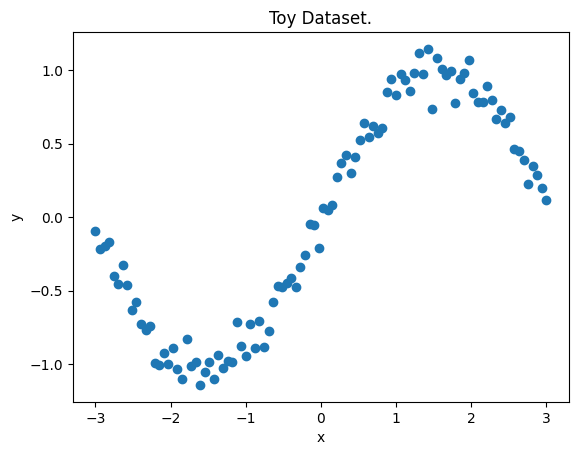

Initial weight: 0.050, Initial bias: -0.014
Step 0, Loss: 0.45172829880627124, w: 0.22679568340090306, b: -0.013138074441576652
Step 20, Loss: 0.1954517987142025, w: 0.33903284271802725, b: -0.010416396541855437
Step 40, Loss: 0.1954517971398298, w: 0.33903284338492196, b: -0.010385017732063413
Step 60, Loss: 0.19545179713962052, w: 0.33903284338492196, b: -0.010384655959017428
Step 80, Loss: 0.1954517971396205, w: 0.33903284338492196, b: -0.010384651788058188
Step 100, Loss: 0.19545179713962046, w: 0.33903284338492196, b: -0.010384651739970309
Step 120, Loss: 0.1954517971396205, w: 0.33903284338492196, b: -0.010384651739415891
Step 140, Loss: 0.1954517971396205, w: 0.33903284338492196, b: -0.010384651739409497
Step 160, Loss: 0.1954517971396205, w: 0.33903284338492196, b: -0.010384651739409442
Step 180, Loss: 0.1954517971396205, w: 0.33903284338492196, b: -0.010384651739409442

Final w: 0.3390, b: -0.0104


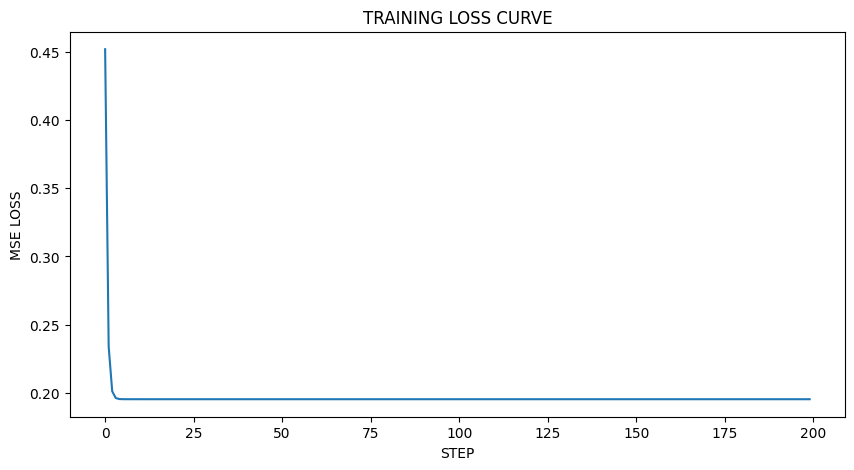

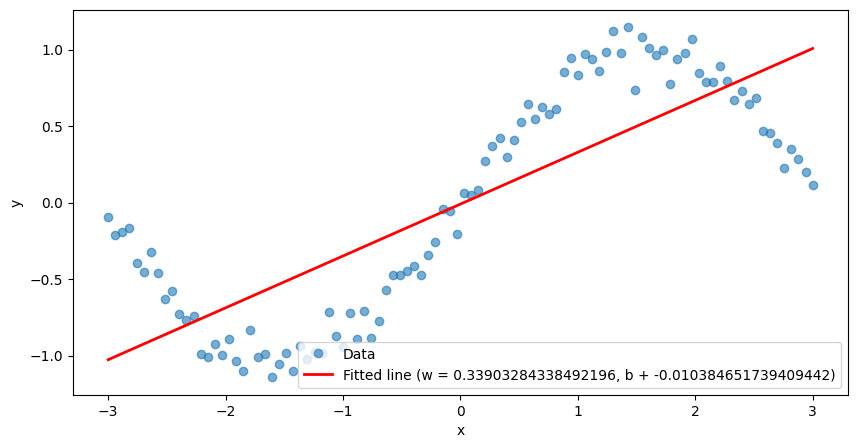

In [8]:

# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

# TODO: Initialise w and b to small random values.

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

#==============================================================================================#
#TODO 1 - Generating toy data and plotting it
np.random.seed(42)

x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1,100)
plt.plot(x,y,"o", label = "Noisy Sine Data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Dataset.")
plt.show()


#TODO 2 - Initialising w and b to small random values
np.random.seed(42)
w = np.random.normal(0, 0.1)
b = np.random.normal(0, 0.1)
print(f"Initial weight: {w:.3f}, Initial bias: {b:.3f}")


#TODO 3 - Implementing ONE gradient-descent step by hand?(oh a calculation by hand, sure) and then looping it for ~200 steps
history_loss = [] # A list to store the losses
lr = 0.1

#A for loop for the 200 steps
for i in range(200):
  y_hat = w * x + b
  loss  = np.mean((y_hat - y) ** 2)
  dw    = np.mean(2 * (y_hat - y) * x)
  db    = np.mean(2 * (y_hat - y))
  w    -= lr * dw
  b    -= lr * db
  #Storing the losses
  history_loss.append(loss)

  #This part is to track the progress of the training process
  if i % 20 ==0:
    print(f"Step {i}, Loss: {loss}, w: {w}, b: {b}")

#Final
print(f"\nFinal w: {w:.4f}, b: {b:.4f}")

#TODO 4 - Plotting the loss curve over the 200 steps and the data with the fitted line on top.

#The loss curve
plt.figure(figsize = (10, 5))
plt.plot(history_loss)
plt.xlabel("STEP")
plt.ylabel("MSE LOSS")
plt.title("TRAINING LOSS CURVE")

plt.show()

#plotting the data with a fitted line on top
plt.figure(figsize = (10,5))
plt.plot(x, y, "o", alpha = 0.6, label = "Data")
plt.plot(x, w * x + b, "r-", linewidth = 2, label = f"Fitted line (w = {w}, b + {b})")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()



**STUDENT REASONING**
1.
/insert image here/

2.
This is **UNDERFITTING**.

Reason: A single neuron computes a linear function (provided in code i.e y_hat = w * x + b), which only represent straight lines. A sine wave however, is a nonlinear function and is oscilatory so no matter how long we train, a linear model like above, will never be able to capture the shape of a sine wave. The loss looks plateaued at the top because we have reached the minimum possible error for a linear model, moreover this loss is still too high since the model is too simple to capture the complexity of the data(It has high bias). In order to fix this, we will need to add non-linearities like hidden layers with activation functiions.